### Required imports

In [1]:
# 1. Standard library
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# 2. Third-party packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

### Importing and splitting the dataset

In [2]:
# Load dataset
df = pd.read_csv("housing.csv")
target = "SalePrice"

In [3]:
percentage_target_null = df[target].isna().sum() / df[target].shape[0]

print(f"{round(percentage_target_null*100, 2)}% of the houses prices are null")

49.98% of the houses prices are null


In [4]:
# Drop rows where target is NaN
df = df.dropna(subset=[target])

# Separate features from the target
X = df.drop(columns=[target])
y = df[target]

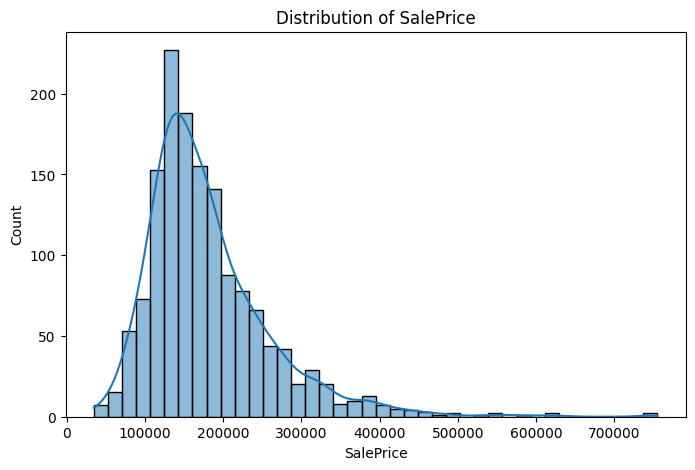

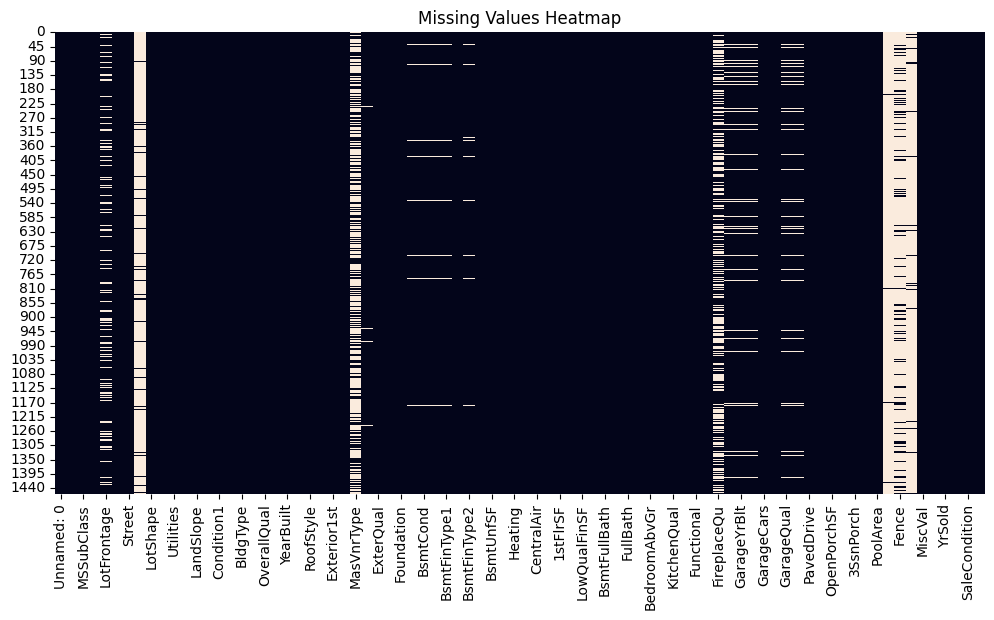

In [5]:
# Target distribution
plt.figure(figsize=(8,5))
sns.histplot(df[target], bins=40, kde=True)
plt.title("Distribution of SalePrice")
plt.show()

# Missing values heatmap
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [6]:
# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=50)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Building the pipelines: ordinal, nominal and mumerical features

In [7]:
# Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

print(f"numeric features = {len(numeric_features)}")
print(f"categorical features = {len(categorical_features)}")

numeric features = 38
categorical features = 43


In [8]:
# Ordinal columns with known quality ordering
ordinal_features = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]
quality_order = [['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']] * len(ordinal_features)

# All other categorical columns -> one-hot
nominal_features = [
    c for c in X_train.select_dtypes(include='object').columns
    if c not in ordinal_features
]

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OrdinalEncoder(
        categories=quality_order,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

nominal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("ord", ordinal_transformer, ordinal_features),
        ("nom", nominal_transformer, nominal_features),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features)
    ]
)

In [9]:
print(f"Number of ordinal columns: {len(ordinal_features)}")
print(f"Number of nominal columns: {len(nominal_features)}")
print(f"Number of numerical columns: {len(numeric_features)}")

Number of ordinal columns: 10
Number of nominal columns: 33
Number of numerical columns: 38


### Training and comparing 3 models

In [10]:
# Candidate models
models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []
best_model_name = None
best_score = -np.inf
best_pipeline = None

In [11]:
# Train and evaluate each model on validation set
for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("feature_selection", SelectKBest(score_func=f_regression, k=12)),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    val_preds = pipeline.predict(X_val)
    
    mae = mean_absolute_error(y_val, val_preds)
    mse = mean_squared_error(y_val, val_preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, val_preds)
    
    results.append([name, mae, mse, rmse, r2])
    
    if r2 > best_score:
        best_score = r2
        best_model_name = name
        best_pipeline = pipeline

In [12]:
# Convert results to DataFrame for pretty table
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R^2"])
print("\nValidation Results:")
print(results_df)

# Evaluate best model on test set
test_preds = best_pipeline.predict(X_test)
test_mae = mean_absolute_error(y_test, test_preds)
test_mse = mean_squared_error(y_test, test_preds)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, test_preds)

print(f"\nBest model: {best_model_name}")
print("\nTest Results:")
test_results_df = pd.DataFrame(
    [[best_model_name, test_mae, test_mse, test_rmse, test_r2]],
    columns=["Model", "MAE", "MSE", "RMSE", "R^2"]
)
print(test_results_df)


Validation Results:
              Model           MAE           MSE          RMSE       R^2
0      DecisionTree  31580.417808  2.365232e+09  48633.655945  0.600842
1      RandomForest  17707.737253  6.221274e+08  24942.481230  0.895010
2  GradientBoosting  16699.238023  5.303595e+08  23029.536153  0.910496

Best model: GradientBoosting

Test Results:
              Model           MAE           MSE          RMSE       R^2
0  GradientBoosting  20361.377677  9.531803e+08  30873.618199  0.865321


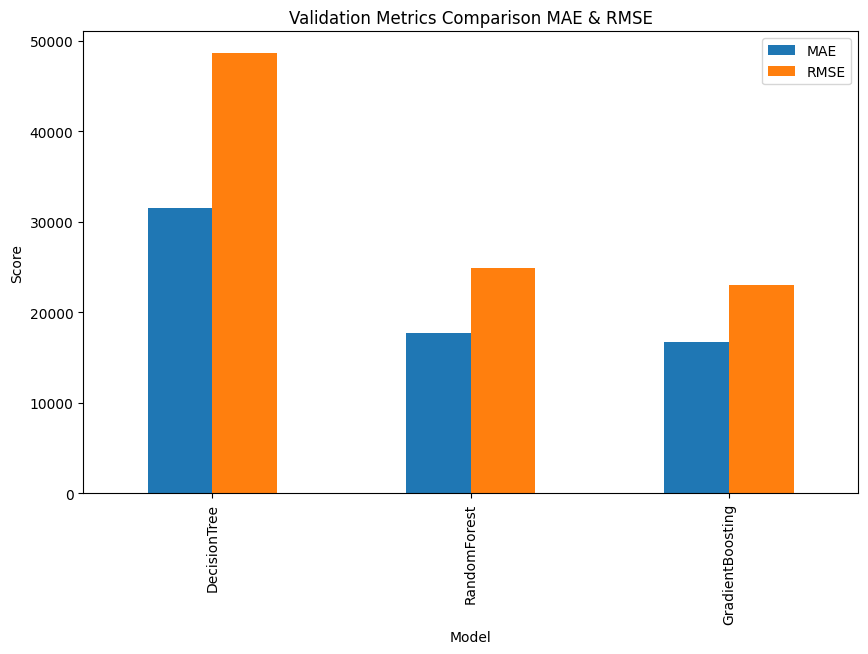

In [13]:
results_df.set_index("Model")[["MAE","RMSE"]].plot(kind="bar", figsize=(10,6))
plt.title("Validation Metrics Comparison MAE & RMSE")
plt.ylabel("Score")
plt.show()

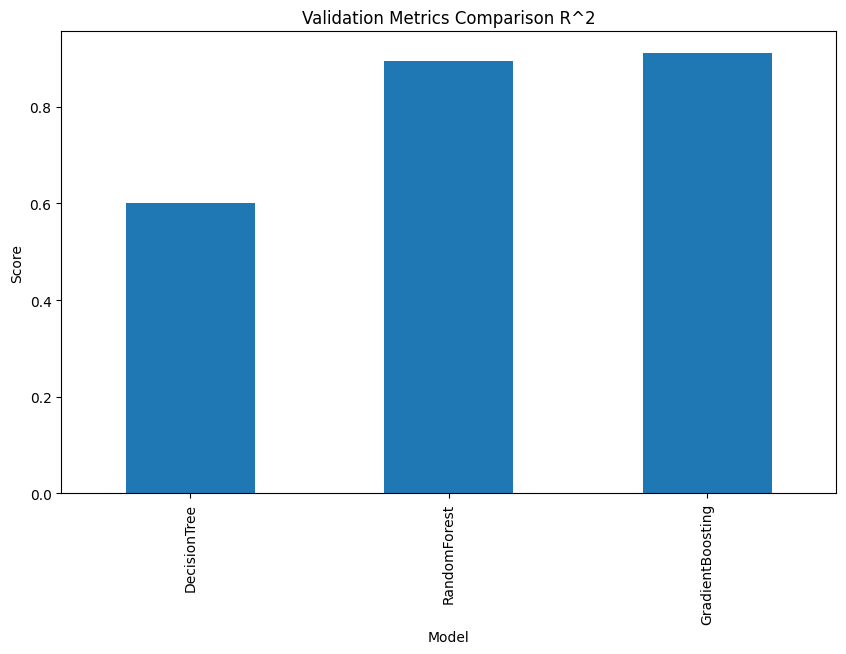

In [14]:
results_df.set_index("Model")["R^2"].plot(kind="bar", figsize=(10,6))
plt.title("Validation Metrics Comparison R^2")
plt.ylabel("Score")
plt.show()

### Feature importance and feature names

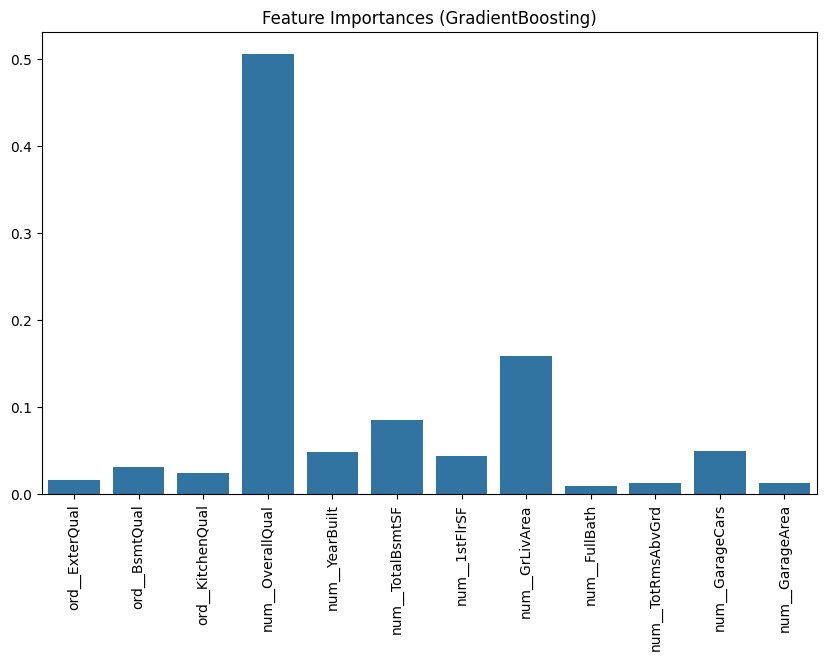

In [15]:
mask = best_pipeline.named_steps["feature_selection"].get_support()
selected = np.array(best_pipeline.named_steps["preprocessor"].get_feature_names_out())[mask]

plt.figure(figsize=(10,6))
sns.barplot(x=selected, y=best_pipeline.named_steps["model"].feature_importances_)
plt.xticks(rotation=90)
plt.title(f"Feature Importances ({best_model_name})")
plt.show()

In [16]:
# Save best pipeline
joblib.dump(best_pipeline, f"best_pipeline_{best_model_name}.joblib")

['best_pipeline_GradientBoosting.joblib']

In [17]:
pipeline = joblib.load("pipeline.joblib")

# Get feature names after preprocessing
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# If you also have feature selection
mask = pipeline.named_steps["feature_selection"].get_support()
selected_features = feature_names[mask]

print(selected_features)

['ord__ExterQual' 'ord__BsmtQual' 'ord__HeatingQC' 'ord__KitchenQual'
 'nom__Neighborhood_NridgHt' 'nom__Foundation_PConc'
 'nom__BsmtFinType1_GLQ' 'nom__GarageType_Detchd' 'nom__GarageFinish_Fin'
 'nom__GarageFinish_Unf' 'num__OverallQual' 'num__GrLivArea']
